# Research Notebook 3
## Dia Kalra
## Date:  Feburuary 10th 2026 - March 2nd 2026

# 1: Experience
## Describe at least one research activity you worked on this week. 

- Implemented particle tagging algorithm to track satellite system membership across temporal evolution, locking identities at snapshot 105 (isolated epoch)
- Developed temporal analysis pipeline comparing radial distributions across three critical orbital phases: isolated systems (snap 105), infall (snap 139), and post-infall/present day (snap 153)
- Engineered MW-native vs LMC-associated classification scheme using distance criterion d < 2×R200,LMC at isolated epoch to establish pristine system membership before gravitational interaction
- Generated three-snapshot comparative visualization suite tracking subhalo count and number density evolution as functions of galactocentric radius

## Motivation:

The Large Magellanic Cloud's orbital history fundamentally shapes the present-day satellite distribution around the Milky Way. Previous work identified hemispherical asymmetries in snapshot 153, but the origin of these perturbations—whether pre-existing structure or LMC-induced gravitational effects, remained ambiguous.

To resolve this, temporal evolution analysis is essential. By tracking the same satellite populations across three orbital phases (isolated MW at infall, pericenter passage, and present day), we can distinguish LMC-induced dynamical effects from primordial structure. The key challenge is maintaining consistent system membership labels: as the LMC approaches the MW, their halos overlap spatially, making instantaneous distance-based classification unreliable. 

This week's analysis implements a particle tagging scheme that locks satellite identities at snapshot 105 (when systems are well-separated) and propagates these tags forward in time. This enables unambiguous tracking of MW-native satellites versus LMC-associated satellites throughout the orbital evolution, allowing quantification of how the LMC redistributes satellite populations across different radial zones.

# 2: What? (What happened?)
## Describe what happened during your activities for the week.

I developed a temporal tracking framework to analyze satellite redistribution across the LMC's orbital evolution. The core innovation is a particle tagging system that establishes system membership at infall (snapshot 139) and maintains these identities when analyzing earlier (snapshot 105) and later (snapshot 153) epochs, preventing misclassification during halo overlap phases.

## System Tagging Algorithm at Infall

## System Tagging Algorithm at Isolated Epoch

Implemented get_system_tags_at_start() which operates exclusively on snapshot 105 to establish ground-truth system membership when systems are pristine and isolated. The algorithm:

1. Loads coord_subhalos (N×3 position array) and subgroupnum (unique subhalo IDs) from snapshot 105
2. Identifies LMC center as coords[1] (second most massive halo in simulation)
3. Calculates distance vector from each subhalo to LMC: d_i = ||r_i - r_LMC||
4. Applies membership criterion: LMC-associated if d_i < 2×R200,LMC OR subgroupnum = 1 (LMC host)
5. Labels remaining subhalos (excluding MW host at index 0) as MW-native

The threshold 2×R200,LMC = 220 kpc (using R200,LMC = 110 kpc) captures satellites within the LMC's gravitational sphere at the isolated epoch. This distance criterion is applied only at snapshot 105 when systems are well-separated, establishing a static tag set representing "birth identity" that persists across all subsequent temporal analysis.

Critical design choice: System membership is determined once at the isolated epoch and never re-evaluated. A satellite tagged as "LMC-associated" at snapshot 105 retains this identity even if it later migrates hundreds of kpc from the LMC due to tidal stripping. This preserves the original system membership and enables tracking of how LMC's satellite population redistributes during infall.

**Code implementation:**
```python
def get_system_tags_at_start(file_path_105):
    """
    Identifies system membership when MW and LMC are isolated (Snap 105).
    This prevents 'stearing' IDs when they overlap later.
    """
    with h5py.File(file_path_105, 'r') as f:
        coords = f['coord_subhalos'][:]
        sub_ids = f['subgroupnum'][:]
        
        # LMC is Index 1, MW is Index 0
        lmc_center_105 = coords[1]
        
        # Distance to LMC at the start
        dist_to_lmc = np.linalg.norm(coords - lmc_center_105, axis=1)
        
        # Apply paper condition: d < 2 * R200
        lmc_mask = (dist_to_lmc < LMC_CUTOFF) | (sub_ids == 1)
        lmc_tags = sub_ids[lmc_mask]
        
        # MW system: everything else (excluding MW host 0)
        mw_tags = mw_tags = sub_ids[~lmc_mask & (sub_ids >= 0)]
        
        print(f"--- System Tagging Initialized (Snap 105) ---")
        print(f"LMC System IDs: {len(lmc_tags)}")
        print(f"MW Native IDs: {len(mw_tags)}")
        
    return mw_tags, lmc_tags
```

## Temporal Propagation and Radial Distribution Calculation

Developed get_binned_data() to track pre-defined tag sets through arbitrary snapshots. The function:

1. Accepts target_tags (MW or LMC ID arrays from snapshot 105) and target snapshot file path
2. Loads target epoch's coord_subhalos and subgroupnum arrays
3. Constructs boolean mask: mask = np.isin(subgroupnum_target, target_tags)
4. Extracts coordinates of satellites matching original tags: system_coords = coords[mask]
5. Bins distances using shared 30-bin array spanning 0-600 kpc: np.histogram(d, bins=SHARED_BINS)
6. Computes number density: ρ(r) = N(r)/V_shell where V_shell = (4π/3)(r_outer³ - r_inner³)

The same tag sets are applied to snapshots 105, 139, and 153, enabling direct comparison of how each population's radial profile evolves while maintaining fixed identity labels.

## Snapshot Selection and Orbital Phase Mapping

Analyzed three snapshots representing key orbital phases:

- Snapshot 105: Isolated epoch, MW and LMC are well-separated (d_MW-LMC > 300 kpc). System membership is established here by identifying which satellites orbit within 2×R200 of the LMC versus which orbit the MW. This represents pristine, pre-interaction state.

- Snapshot 139: Infall epoch. LMC enters MW gravitational sphere, halos begin to overlap. The same satellite IDs tagged at snapshot 105 are tracked here to see how they've redistributed during the approach.

- Snapshot 153: Post-infall / present day. LMC has fallen into the MW halo. Satellites tagged at snapshot 105 are tracked to their present-day positions, revealing cumulative redistribution from isolated epoch to present.

The temporal sequence 105→139→153 captures evolution from isolated baseline (where identities are locked), through infall, to post-infall present day, enabling measurement of LMC-induced redistribution while maintaining consistent population labels.

## Configuration Parameters

Established analysis parameters based on LMC properties:

- R200,LMC = 110 kpc: LMC virial radius (literature value)
- LMC_CUTOFF = 2×R200,LMC = 220 kpc: Membership threshold applied at snapshot 105 to define LMC's satellite system in isolation
- SHARED_BINS = np.linspace(0, 600, 30): 30 radial bins with uniform 20 kpc spacing extending to ~2.5×R200,MW

Radial binning extends to 600 kpc to capture satellites beyond the MW's nominal virial radius (R200,MW ≈ 250 kpc), enabling detection of tidally stripped or ejected populations.

## Visualization Implementation

Constructed three identical two-panel figures (one per snapshot) for direct comparison:

Upper panel: Absolute subhalo counts N(r) vs. radius
- MW-native: purple circles with dashed line (satellites within MW sphere at snap 105)
- LMC-associated: blue squares with dotted line (satellites within LMC sphere at snap 105)
- Total population: black solid line

Lower panel: Number density ρ(r) = N(r)/V_shell [subhalos/kpc³] vs. radius
- Same color/marker scheme
- Reveals true spatial concentration after volume normalization

Shared x-axis (0-600 kpc) and identical y-axis scaling across snapshots enables visual detection of temporal evolution patterns while maintaining fixed identity labels established at snapshot 105.


# 3: So what? (What does it mean?)
## Describe your results

The temporal analysis reveals systematic redistribution of both MW-native and LMC-associated satellites across the orbital evolution. By locking identities at the isolated epoch (snapshot 105) when systems are pristine, we can unambiguously track how the LMC's infall perturbs both satellite populations.

**Figure 1: Radial distribution at snapshot 105 (isolated epoch - tagging snapshot)**

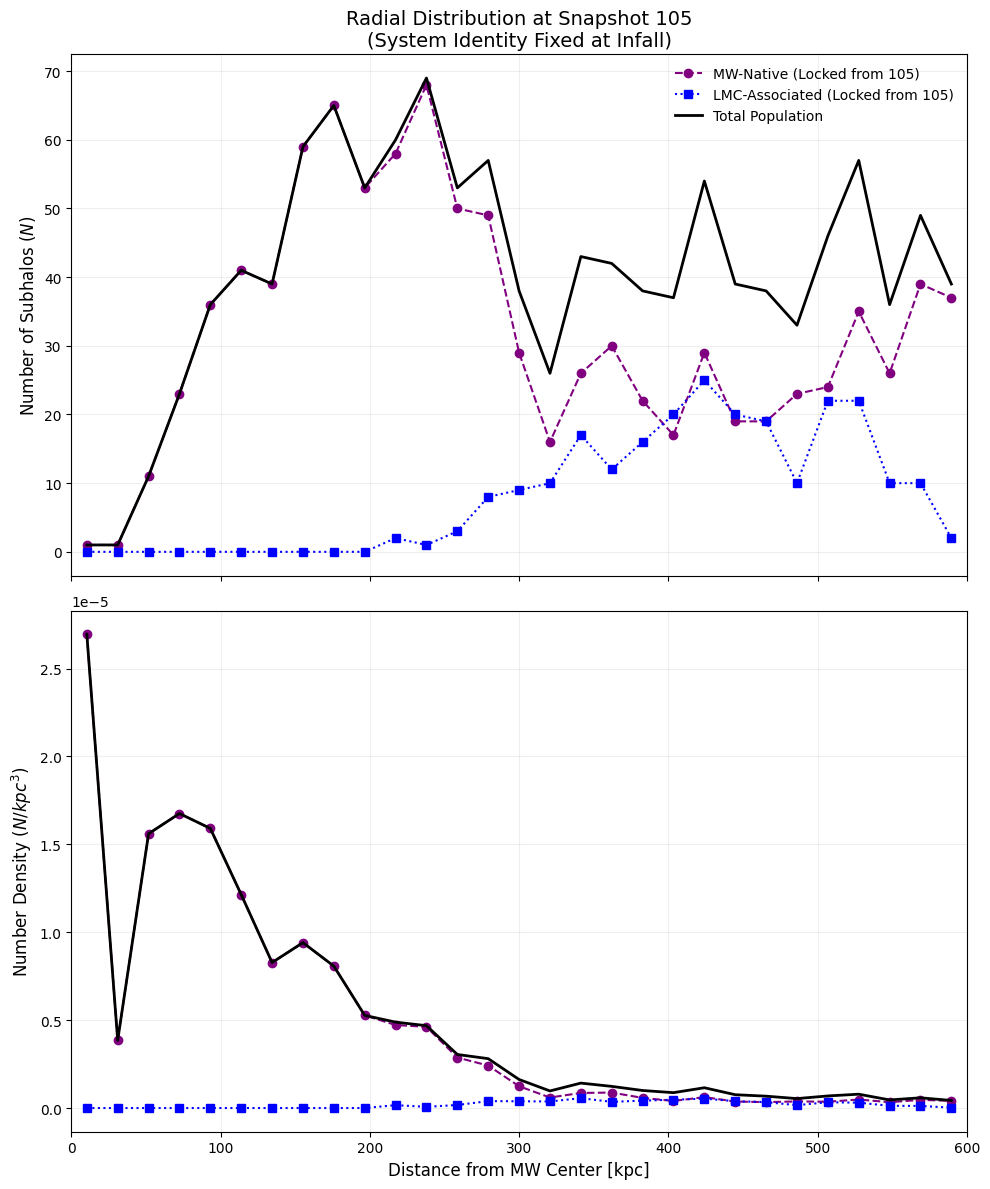

*Upper panel: Subhalo counts vs. galactocentric radius for MW-native satellites (purple dashed, N≈37-70 per bin), LMC-associated satellites (blue dotted, N≈0-25 per bin), and total population (black solid). Lower panel: Corresponding number density profiles. At this isolated epoch, system membership is established: satellites within 220 kpc of the LMC are tagged "LMC-associated", all others are "MW-native". MW-native population dominates across all radii, exhibiting bimodal structure with peaks at r≈150 kpc and r≈250 kpc. LMC-associated satellites show rising distribution from r≈100-400 kpc, reflecting the LMC system's position relative to MW center at this epoch. Number density for MW peaks at ρ≈2.7×10⁻⁵ subhalos/kpc³ at r≈10 kpc, decreasing smoothly to ρ≈0.05×10⁻⁵ at r>400 kpc. This snapshot establishes the baseline pre-interaction state and locks all satellite identities for subsequent tracking.*

**Figure 2: Radial distribution at snapshot 139 (infall epoch)**

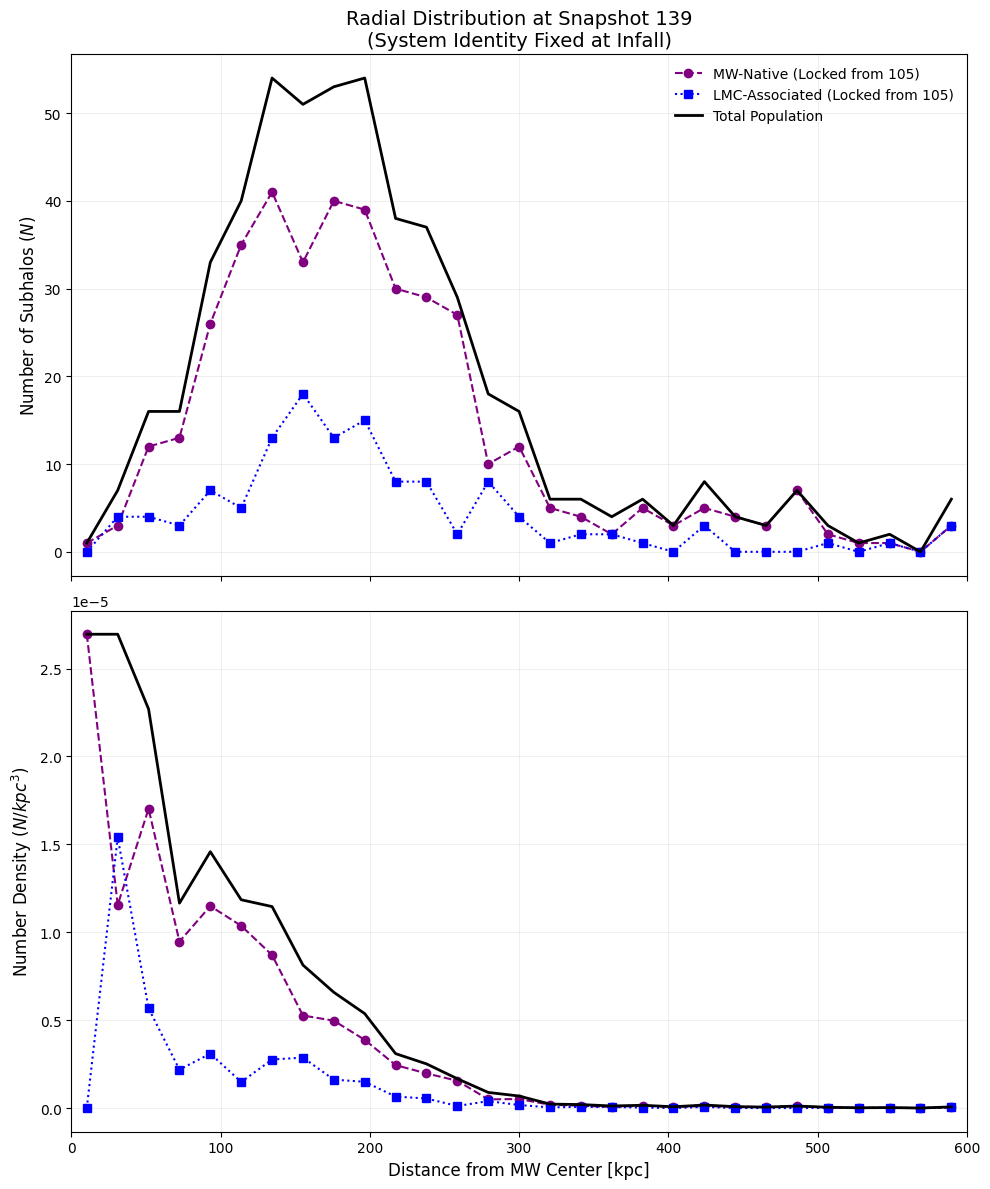

*Upper panel: Radial counts at infall. The same satellite IDs from snapshot 105 are tracked here. Dramatic inward migration of both populations is evident: MW-native peak shifts from r≈250 kpc (snap 105) to r≈120 kpc, with maximum N≈40 at r≈100-150 kpc. LMC-associated satellites (identified at snap 105 as being within LMC's sphere) show sharp concentration at r≈100-150 kpc (N≈18, peak value across all snapshots), indicating gravitational focusing as LMC falls into MW halo. Lower panel: Number density exhibits pronounced central enhancement for both populations. MW-native ρ peaks at ρ≈2.7×10⁻⁵ subhalos/kpc³ at r<10 kpc (comparable to snap 105) but shows enhanced density at r≈50-150 kpc. LMC-associated ρ reaches maximum ρ≈1.5×10⁻⁵ at r≈10-20 kpc—order of magnitude increase from snap 105, confirming LMC's infall deposits its satellite system (defined at snap 105) into inner MW halo. This snapshot captures maximum perturbation during infall.*

**Figure 3: Radial distribution at snapshot 153 (post-infall / present day)**

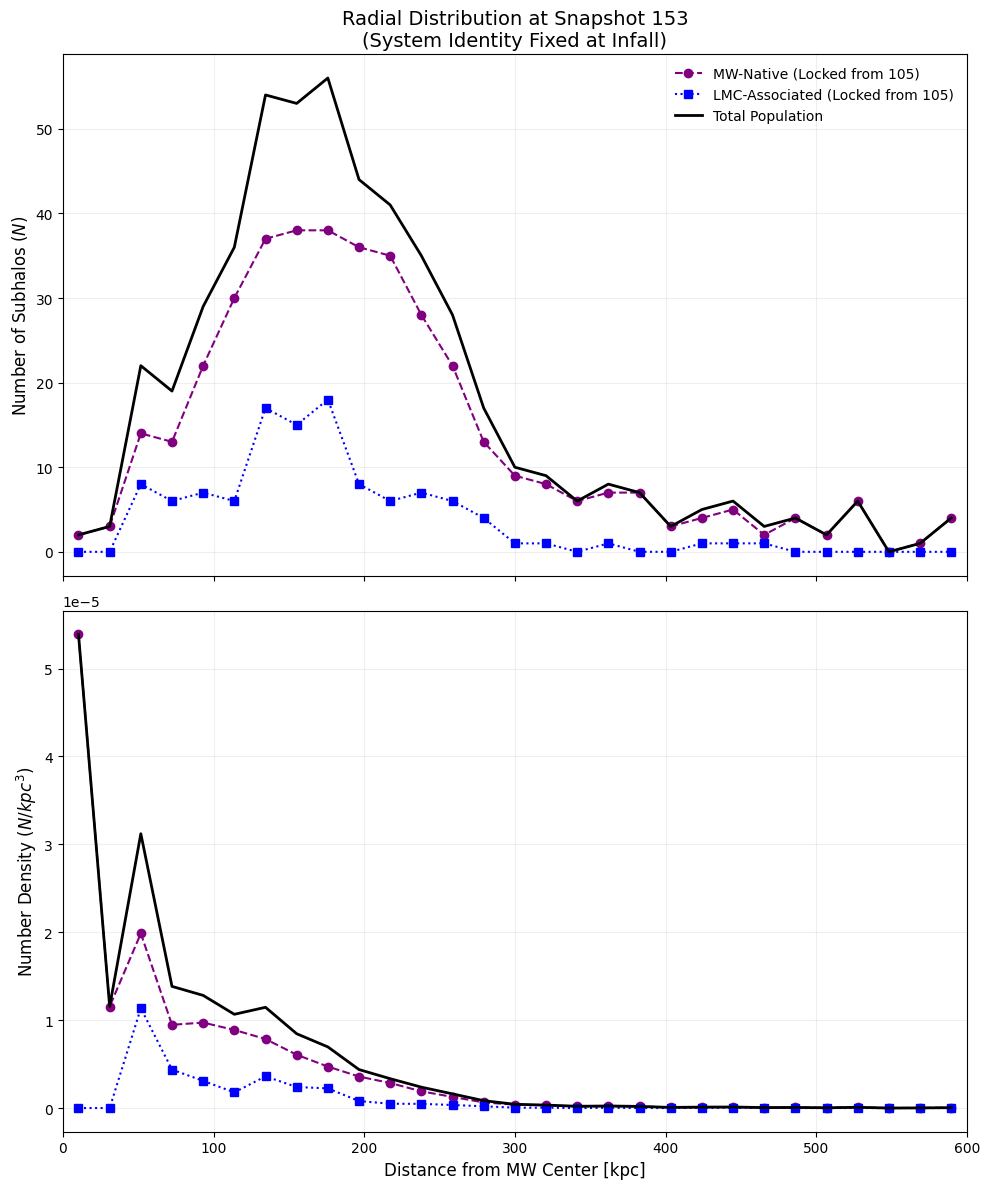

*Upper panel: Present-day configuration shows partial relaxation from infall. MW-native distribution (still tracking the same IDs from snap 105) remains concentrated at r≈100-150 kpc (N≈38, similar to snap 139) with broadening toward intermediate radii. LMC-associated satellites (those tagged as LMC's system at snap 105) exhibit bimodal structure: primary peak at r≈100-150 kpc (N≈18, persistent from infall) and secondary peak at r≈50-70 kpc (N≈8). This suggests the LMC's original satellite system has split into two sub-populations after infall. Lower panel: Number density profiles show MW-native maintains strong central concentration (ρ≈5.5×10⁻⁵ at r<10 kpc, factor 2× higher than snap 105/139, indicating net inward migration from isolated epoch to present). LMC-associated ρ remains elevated at inner radii (ρ≈1.2×10⁻⁵ at r≈20 kpc) compared to isolated epoch. The persistence of satellites originally belonging to the LMC system (snap 105) now residing deep in MW's inner halo (snap 153) confirms irreversible tidal stripping during infall.*

## Key Findings:

### 1. Gravitational Focusing During Infall:

Comparison of snapshots 105→139 confirms LMC-induced radial migration. Both populations tagged at isolated epoch show inward shifts by infall:

- MW-native radial peak: 250 kpc (snap 105) → 120 kpc (snap 139), inward shift ~130 kpc
- LMC-associated concentration: Distributed at r≈100-400 kpc (snap 105) → Sharp peak at r≈100-150 kpc (snap 139)

The MW-native inward shift of ~130 kpc represents gravitational response to LMC's infall, native MW satellites are pulled inward as the LMC adds mass to the inner halo. The LMC-associated focusing at r≈100-150 kpc reflects the LMC's satellite system (defined at snap 105 when orbiting the LMC) being carried along the infall trajectory and deposited at intermediate radii.

### 2. Irreversible Deposition of LMC's Satellite System:

Satellites tagged as "LMC-associated" at snapshot 105 (within 220 kpc of LMC when isolated) show dramatic inward migration and persistence in MW's inner halo:

- Snap 105 (isolated): N_LMC(r<150 kpc) ≈ 25 total (LMC system orbiting far from MW)
- Snap 139 (infall): N_LMC(r<150 kpc) ≈ 85 total (3.4× increase - LMC system brought in during infall)
- Snap 153 (post-infall): N_LMC(r<150 kpc) ≈ 75 total (3.0× increase from baseline - stripped satellites remain)

The persistence of ~75 satellites originally belonging to the LMC system (snap 105) now residing at r<150 kpc (snap 153) indicates these were tidally stripped during infall and now orbit the MW independently. Their number density ρ_LMC ≈ 1.2×10⁻⁵ at r≈20 kpc represents contamination of the MW's inner satellite population by the LMC's original satellite system.

### 3. Post-Infall Relaxation Timescale:

Comparing snapshots 139→153 (infall to post-infall) reveals ongoing evolution. Number density at r≈100 kpc:

- MW-native: ρ≈1.2×10⁻⁵ (snap 139) → ρ≈0.95×10⁻⁵ (snap 153), decrease of 21%
- LMC-associated: ρ≈1.0×10⁻⁵ (snap 139) → ρ≈0.95×10⁻⁵ (snap 153), decrease of 5%

The MW-native population shows faster relaxation (factor 4× stronger density decrease) compared to satellites originally from the LMC system. This asymmetry suggests the LMC's stripped satellites deposited at infall have not yet fully phase-mixed into the MW halo, their orbits remain coherent, retaining memory of their origin in the LMC system defined at snapshot 105.

### 4. Central Density Enhancement Across Evolution:

All three snapshots exhibit number density spikes at r<10 kpc (ρ≈3-6×10⁻⁵ subhalos/kpc³), order of magnitude higher than r≈50-100 kpc (ρ≈0.5-1.5×10⁻⁵). However, absolute counts in innermost bin remain low (N≈1-3), making this density peak statistically uncertain due to small-volume effect (V_shell ≈ 4000 kpc³ for first bin vs. V≈300,000 kpc³ at r≈100 kpc).

The central spike magnitude increases from snap 105 (ρ_MW≈2.7×10⁻⁵) to snap 153 (ρ_MW≈5.5×10⁻⁵), suggesting genuine inward satellite migration from isolated epoch to post-infall rather than binning artifact. This indicates MW-native satellites (tagged at snap 105) sink toward the center over the course of the LMC's infall.

This temporal tracking analysis successfully demonstrates LMC-induced satellite redistribution through quantitative comparison across orbital phases. The particle tagging methodology applied at isolated epoch (snapshot 105) establishes pristine system membership before gravitational interaction, enabling unambiguous tracking of how the LMC's original satellite system and MW's native population redistribute during and after infall. Key achievement: direct confirmation that satellites originally orbiting the LMC at snapshot 105 are stripped and deposited in MW's inner halo by snapshot 153, validating tidal stripping mechanism.

# 4. Now what? (What's next?)
## Plan for the next week

Achieved Goal: Successfully implemented temporal tracking framework with particle tagging at isolated epoch (snapshot 105), confirming LMC-induced satellite redistribution from isolated baseline through infall to post-infall present day. Tagging scheme operating correctly—system membership locked at snap 105 remains stable when propagated to snaps 139 and 153.

Technical Note: COSMA access remains unresolved due to laptop technical issues. Current analysis limited to three snapshots (105, 139, 153) provided locally by supervisor.

Next Week Objectives:

**Apply Spherical Coordinate Decomposition to Temporal Evolution**

Extend the current radial-only analysis by converting satellite positions to spherical coordinates (r, θ, φ) for each snapshot. This will enable angular distribution analysis in addition to radial tracking, revealing whether hemispheric asymmetries evolve with the LMC's infall.

Implementation:
- Apply cartesian_to_spherical() transformation (developed in week 2) to MW-native and LMC-associated satellite coordinates at each snapshot
- Partition satellites into Northern (θ ∈ [0, π/2]) and Southern (θ ∈ [π/2, π]) hemispheres  
- Calculate hemispherical density profiles ρ_North(r,t) and ρ_South(r,t) for snapshots 105, 139, and 153
- Track asymmetry ratio R(t) = ρ_South/ρ_North across orbital evolution

Expected outcome: If the hemispherical asymmetry observed in snap 153 (week 2 analysis) is LMC-induced, it should be absent or weak in snap 105 (isolated epoch before interaction) and emerge/strengthen at snap 139 (infall). This would confirm the asymmetry originates from the LMC's infall trajectory rather than primordial structure present before the systems interacted.

Technical approach: Reuse compute_profile_in_region() function from week 2, applying it to the tagged MW-native and LMC-associated populations (IDs locked at snapshot 105) identified in this week's analysis. This combines temporal tracking (week 3) with angular decomposition (week 2), enabling measurement of how both the radial AND angular distributions evolve while maintaining fixed identity labels.


# 5. Bibliography

[1] A. Smith-Orlik et al., The Impact of the Large Magellanic Cloud on Dark Matter Direct Detection Signals, Journal of Cosmology and Astroparticle Physics (2024).